# 06 — Analise Profunda da Comunidade
## Estruturas de Rede, Arquetipos de Usuarios e Padroes Comportamentais nas Respostas de Trump vs AOC

Enquanto os notebooks anteriores analisaram *o que* os politicos publicam e *quanto* engajamento recebem, este notebook muda o foco para a **propria comunidade** — as pessoas que respondem. Usando metodologia netnografica (Kozinets, 2015), examinamos:

- **Topologia da rede de respostas**: Quem menciona quem nas secoes de resposta?
- **Lideres de opiniao**: Quais respondentes conduzem a conversa?
- **Clusters da comunidade**: Existem grupos comportamentais distintos?
- **Arquetipos de usuarios**: Apoiadores, criticos, trolls e bots
- **Profundidade da conversa**: Quao profundas sao as threads de resposta?
- **Comportamento longitudinal**: Como o engajamento evolui ao longo do tempo?
- **Engajamento entre perfis**: Os mesmos usuarios interagem com ambos os politicos?

In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from utils.data_loader import load_tweets, load_replies, load_user_profiles, load_mention_network
from utils.plot_helpers import setup_style, get_colors, get_user_label, format_large_numbers, set_language
from config import FIGURE_SIZE, FIGURE_SIZE_SMALL, FIGURE_SIZE_LARGE, RANDOM_SEED, ARCHETYPE_COLORS

set_language('pt-br')
setup_style()
colors = get_colors()
np.random.seed(RANDOM_SEED)

In [2]:
df = load_tweets()
replies_df = load_replies()
profiles = load_user_profiles()
mention_edges = load_mention_network()

print(f"\nResumo do dataset:")
print(f"  Tweets: {len(df)}")
print(f"  Respostas: {len(replies_df)}")
print(f"  Respondentes unicos: {len(profiles)}")
print(f"  Arestas da rede de mencoes: {len(mention_edges)}")

Loaded 200 tweets from processed/
Loaded 11403 replies from processed/
Loaded 7980 user profiles from processed/
Loaded 5036 mention edges from processed/

Resumo do dataset:
  Tweets: 200
  Respostas: 11403
  Respondentes unicos: 7980
  Arestas da rede de mencoes: 5036


---
## 1. A Rede de Respostas: Quem Fala com Quem?

Visao geral da rede:
  Nos: 4,395
  Arestas: 5,036
  Densidade: 0.000261
  Grau de entrada medio: 1.15
  Grau de saida medio: 1.15


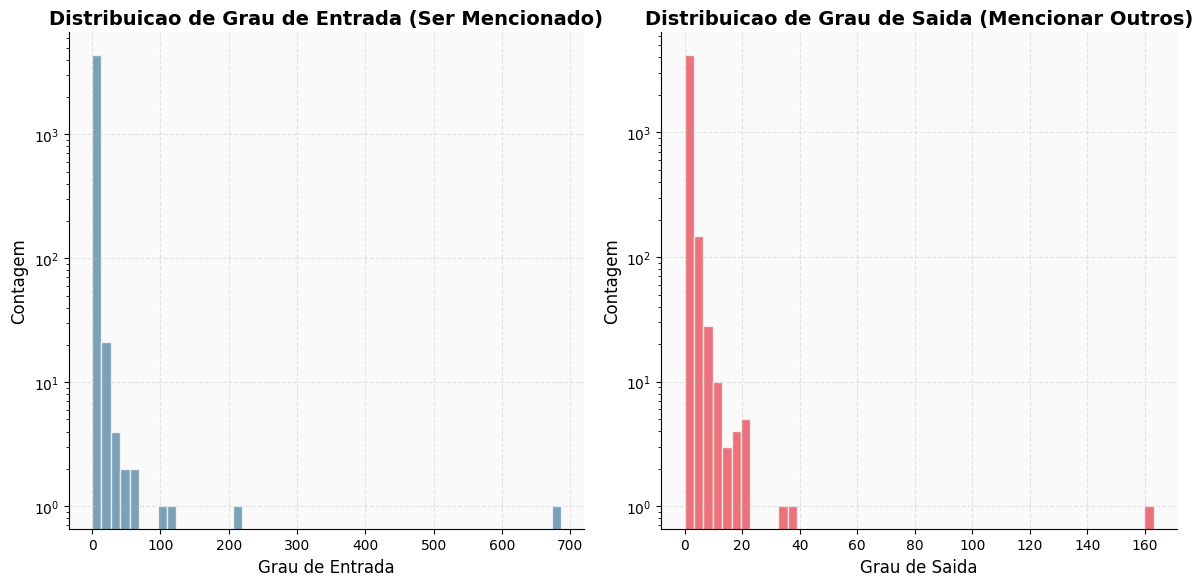

In [3]:
# Construir grafo dirigido a partir das arestas de mencao
G = nx.DiGraph()
for _, row in mention_edges.iterrows():
    G.add_edge(row['source'], row['target'], weight=row['weight'])

print(f"Visao geral da rede:")
print(f"  Nos: {G.number_of_nodes():,}")
print(f"  Arestas: {G.number_of_edges():,}")
print(f"  Densidade: {nx.density(G):.6f}")
print(f"  Grau de entrada medio: {np.mean([d for _, d in G.in_degree()]):.2f}")
print(f"  Grau de saida medio: {np.mean([d for _, d in G.out_degree()]):.2f}")

# Distribuicoes de grau
fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

in_degrees = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

axes[0].hist(in_degrees, bins=50, color=colors['aoc'], alpha=0.7, edgecolor='white')
axes[0].set_title('Distribuicao de Grau de Entrada (Ser Mencionado)', fontweight='bold')
axes[0].set_xlabel('Grau de Entrada')
axes[0].set_ylabel('Contagem')
axes[0].set_yscale('log')

axes[1].hist(out_degrees, bins=50, color=colors['trump'], alpha=0.7, edgecolor='white')
axes[1].set_title('Distribuicao de Grau de Saida (Mencionar Outros)', fontweight='bold')
axes[1].set_xlabel('Grau de Saida')
axes[1].set_ylabel('Contagem')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

**O que isso nos diz?** As distribuicoes de grau seguem um padrao de lei de potencia — a maioria dos usuarios menciona (ou e mencionada por) muito poucos outros, enquanto um pequeno numero de usuarios funciona como hubs da rede. Isso e tipico de comunidades politicas online onde poucos participantes vocais dominam a estrutura da conversa.

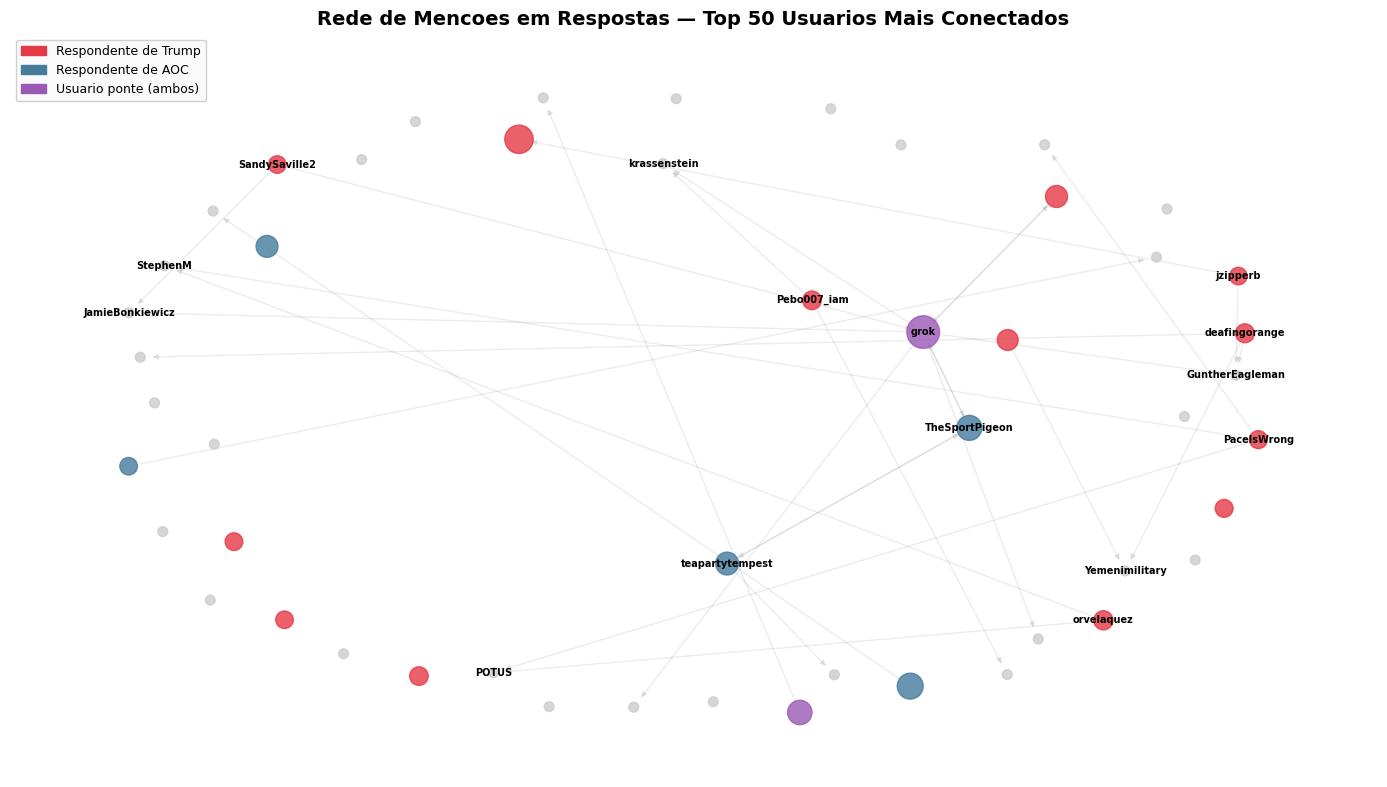

In [4]:
# Visualizacao da rede: top 50 nos mais conectados
top_nodes = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)[:50]
subG = G.subgraph(top_nodes)

profiles_map = profiles.set_index('user_name')
node_colors_map = []
node_sizes = []
for node in subG.nodes():
    if node in profiles_map.index:
        p = profiles_map.loc[node]
        if p.get('is_cross_profile', False):
            node_colors_map.append('#9B59B6')
        elif p.get('trump_replies', 0) > p.get('aoc_replies', 0):
            node_colors_map.append(colors['trump'])
        else:
            node_colors_map.append(colors['aoc'])
        followers = max(p.get('user_followers_count', 100), 100)
        node_sizes.append(min(np.log10(followers) * 80, 800))
    else:
        node_colors_map.append('#CCCCCC')
        node_sizes.append(50)

fig, ax = plt.subplots(figsize=FIGURE_SIZE_LARGE)
pos = nx.spring_layout(subG, seed=RANDOM_SEED, k=2)

nx.draw_networkx_edges(subG, pos, alpha=0.15, edge_color='gray',
                        arrows=True, arrowsize=8, ax=ax)
nx.draw_networkx_nodes(subG, pos, node_color=node_colors_map,
                        node_size=node_sizes, alpha=0.8, ax=ax)

top_15 = sorted(subG.nodes(), key=lambda n: subG.degree(n), reverse=True)[:15]
labels = {n: n for n in top_15}
nx.draw_networkx_labels(subG, pos, labels, font_size=7, font_weight='bold', ax=ax)

legend_patches = [
    mpatches.Patch(color=colors['trump'], label='Respondente de Trump'),
    mpatches.Patch(color=colors['aoc'], label='Respondente de AOC'),
    mpatches.Patch(color='#9B59B6', label='Usuario ponte (ambos)'),
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
ax.set_title('Rede de Mencoes em Respostas — Top 50 Usuarios Mais Conectados', fontweight='bold', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

**O que isso nos diz?** A visualizacao da rede revela a estrutura da comunidade dentro da secao de respostas de cada politico. O tamanho do no reflete a contagem de seguidores (influencia), enquanto a cor mostra com qual politico o usuario se engaja principalmente. Usuarios ponte (roxo) que interagem com ambos sao raros — uma representacao visual das camaras de eco politicas.

---
## 2. Lideres de Opiniao: Quem Conduz a Conversa?

In [5]:
# Analise de centralidade
pagerank = nx.pagerank(G, weight='weight')
betweenness = nx.betweenness_centrality(G, weight='weight', k=min(500, G.number_of_nodes()))

centrality_df = pd.DataFrame({
    'user_name': list(pagerank.keys()),
    'pagerank': list(pagerank.values()),
    'betweenness': [betweenness.get(n, 0) for n in pagerank.keys()],
    'in_degree': [G.in_degree(n) for n in pagerank.keys()],
    'out_degree': [G.out_degree(n) for n in pagerank.keys()],
})

centrality_df = centrality_df.merge(
    profiles[['user_name', 'user_followers_count', 'archetype', 'trump_replies', 'aoc_replies']],
    on='user_name', how='left'
)
centrality_df['primary_politician'] = np.where(
    centrality_df['trump_replies'].fillna(0) > centrality_df['aoc_replies'].fillna(0),
    'Trump', 'AOC'
)

top_leaders = centrality_df.nlargest(15, 'pagerank')[
    ['user_name', 'primary_politician', 'user_followers_count', 'pagerank',
     'in_degree', 'archetype']
].reset_index(drop=True)
top_leaders.index += 1
top_leaders.columns = ['Usuario', 'Politico Principal', 'Seguidores', 'PageRank', 'Grau Entrada', 'Arquetipo']
top_leaders['PageRank'] = top_leaders['PageRank'].apply(lambda x: f"{x:.5f}")
top_leaders['Seguidores'] = top_leaders['Seguidores'].apply(lambda x: f"{x:,.0f}" if pd.notna(x) else 'N/A')

print("Top 15 Lideres de Opiniao por PageRank:")
display(top_leaders)

Top 15 Lideres de Opiniao por PageRank:


,Usuario,Politico Principal,Seguidores,PageRank,Grau Entrada,Arquetipo
1,SenateDems,AOC,N/A,0.06751,686,NaN
2,DianaforQueens,AOC,N/A,0.02572,219,NaN
3,grok,Trump,"8,104,538",0.01492,114,casual
4,SenSchumer,AOC,N/A,0.00573,107,NaN
5,F15Synch,AOC,N/A,0.00492,44,NaN
6,Yemenimilitary,AOC,N/A,0.00442,55,NaN
7,GuntherEagleman,AOC,N/A,0.00367,57,NaN
8,krassenstein,AOC,N/A,0.00345,42,NaN
9,StephenM,AOC,N/A,0.00337,30,NaN
10,allgoodmight,Trump,"1,342",0.00302,12,casual


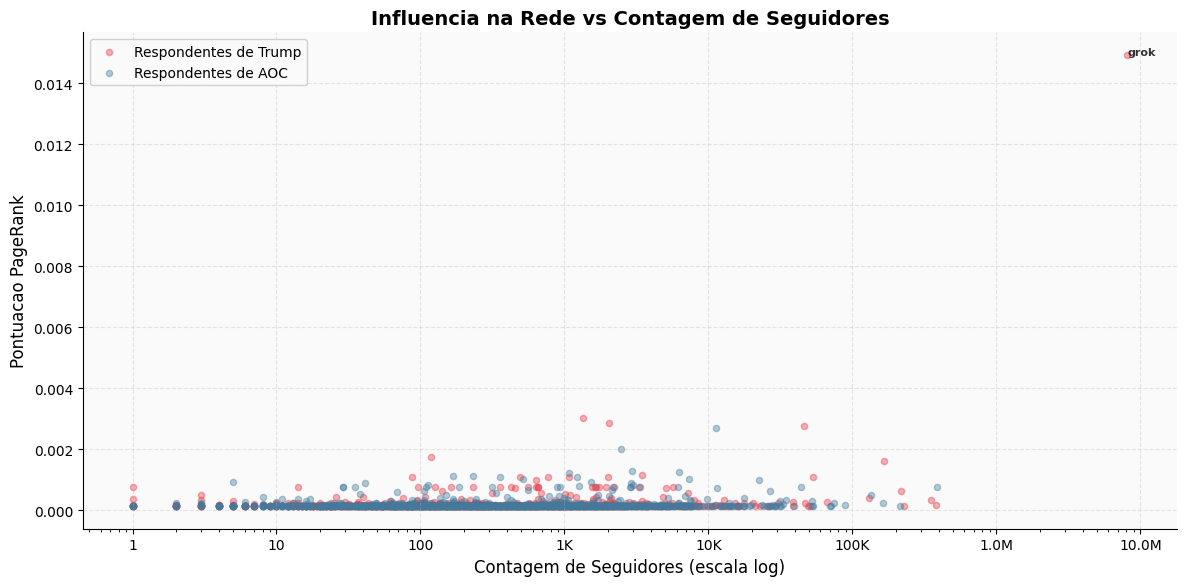

In [6]:
# Scatter: seguidores vs PageRank
plot_df = centrality_df[centrality_df['user_followers_count'].notna()].copy()
plot_df = plot_df[plot_df['user_followers_count'] > 0]

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
for pol, color in [('Trump', colors['trump']), ('AOC', colors['aoc'])]:
    mask = plot_df['primary_politician'] == pol
    ax.scatter(plot_df[mask]['user_followers_count'], plot_df[mask]['pagerank'],
              alpha=0.4, color=color, label=f'Respondentes de {pol}', s=20)

for _, row in centrality_df.nlargest(5, 'pagerank').iterrows():
    if row['user_name'] in plot_df['user_name'].values:
        ax.annotate(row['user_name'],
                   (row['user_followers_count'], row['pagerank']),
                   fontsize=8, fontweight='bold', alpha=0.8)

ax.set_xscale('log')
ax.set_xlabel('Contagem de Seguidores (escala log)')
ax.set_ylabel('Pontuacao PageRank')
ax.set_title('Influencia na Rede vs Contagem de Seguidores', fontweight='bold')
ax.legend()
format_large_numbers(ax, 'x')
plt.tight_layout()
plt.show()

**O que isso nos diz?** O PageRank mede a influencia real *dentro da rede de respostas*, enquanto a contagem de seguidores mede o capital social externo. Usuarios com alto PageRank mas poucos seguidores sao influenciadores especificos da comunidade — pessoas que podem nao ser famosas mas sao centrais no discurso politico nestas threads.

---
## 3. Clusters da Comunidade: Existem Grupos Distintos?

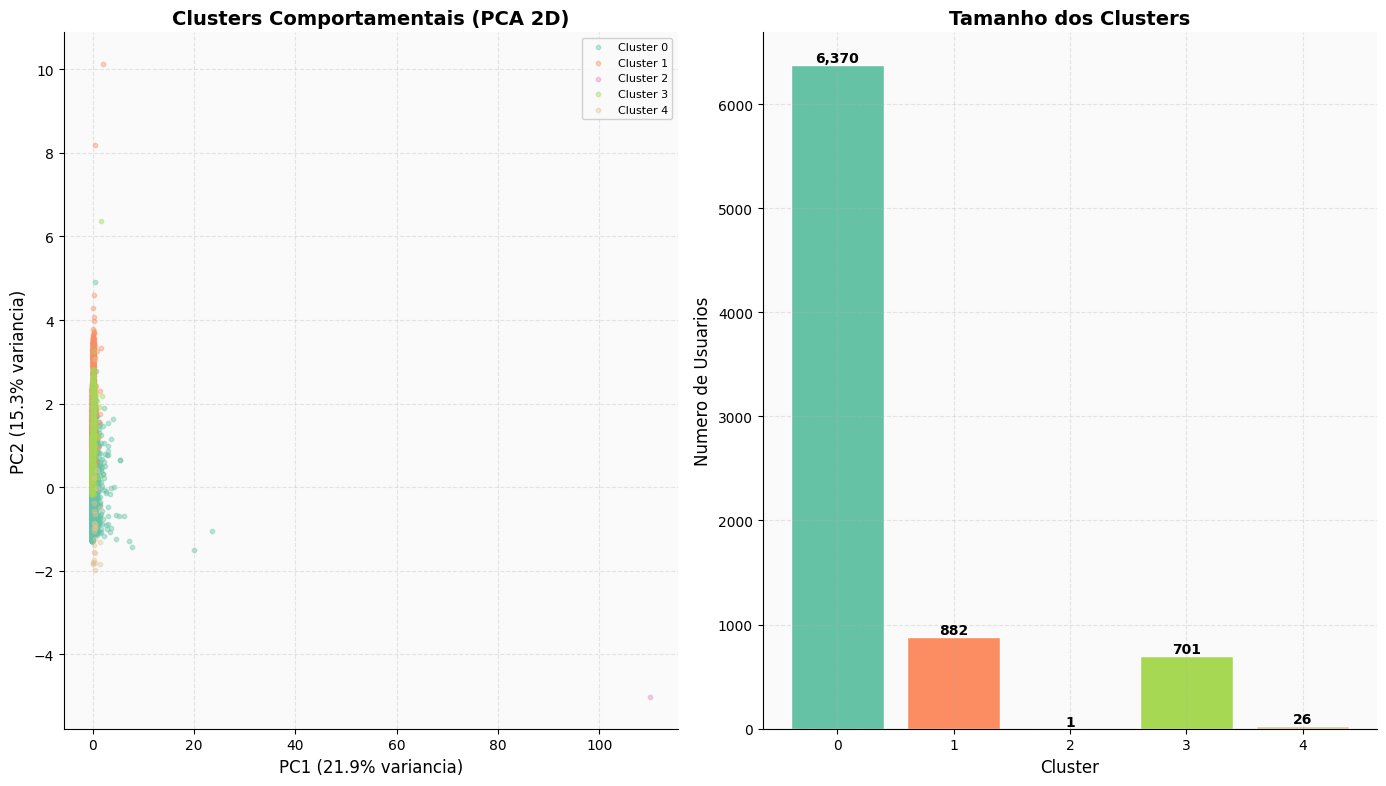

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

feature_cols = [
    'total_replies', 'avg_text_length', 'avg_favorites_received',
    'user_followers_count', 'negative_pct', 'positive_pct',
    'mentions_parent_pct', 'avg_reply_delay_minutes',
]
X = profiles[feature_cols].fillna(0).values
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)

cluster_cmap = plt.cm.Set2
for cluster_id in sorted(profiles['behavior_cluster'].unique()):
    mask = profiles['behavior_cluster'] == cluster_id
    axes[0].scatter(coords[mask, 0], coords[mask, 1],
                   alpha=0.4, s=10, label=f'Cluster {cluster_id}',
                   color=cluster_cmap(cluster_id / 5))
axes[0].set_title('Clusters Comportamentais (PCA 2D)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variancia)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variancia)')
axes[0].legend(fontsize=8)

cluster_sizes = profiles['behavior_cluster'].value_counts().sort_index()
bars = axes[1].bar(cluster_sizes.index, cluster_sizes.values,
                   color=[cluster_cmap(i/5) for i in cluster_sizes.index],
                   edgecolor='white')
for bar, val in zip(bars, cluster_sizes.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
               f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Tamanho dos Clusters', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Numero de Usuarios')

plt.tight_layout()
plt.show()

In [8]:
# Tabela comparativa de clusters
cluster_stats = profiles.groupby('behavior_cluster').agg(
    usuarios=('user_name', 'count'),
    media_respostas=('total_replies', 'mean'),
    media_seguidores=('user_followers_count', 'mean'),
    media_curtidas=('avg_favorites_received', 'mean'),
    media_texto=('avg_text_length', 'mean'),
    positivo_pct=('positive_pct', 'mean'),
    negativo_pct=('negative_pct', 'mean'),
).round(2)

cluster_stats.columns = ['Usuarios', 'Media Respostas', 'Media Seguidores', 'Media Curtidas',
                          'Media Texto', 'Positivo %', 'Negativo %']
print("Perfis comportamentais dos clusters:")
display(cluster_stats)

print("\nDistribuicao de clusters por politico principal:")
profiles['politico_principal'] = np.where(
    profiles['trump_replies'] > profiles['aoc_replies'], 'Trump', 'AOC'
)
cross_tab = pd.crosstab(profiles['behavior_cluster'], profiles['politico_principal'],
                         normalize='index').round(3) * 100
cross_tab.columns = [f'{c} %' for c in cross_tab.columns]
display(cross_tab)

Perfis comportamentais dos clusters:


,Usuarios,Media Respostas,Media Seguidores,Media Curtidas,Media Texto,Positivo %,Negativo %
behavior_cluster,,,,,,,
0,6370,1.44,1445.21,0.36,93.58,0.01,0.01
1,882,1.20,1204.78,0.40,154.83,0.00,0.95
2,1,233.00,8104538.00,0.18,272.87,0.08,0.06
3,701,1.22,1497.86,0.49,147.37,0.93,0.01
4,26,2.27,5079.77,0.38,93.98,0.11,0.06



Distribuicao de clusters por politico principal:


,AOC %,Trump %
behavior_cluster,,
0,42.8,57.2
1,57.8,42.2
2,0.0,100.0
3,33.0,67.0
4,19.2,80.8


**O que isso nos diz?** O clustering KMeans revela grupos comportamentais naturalmente ocorrentes. O maior cluster representa respondentes tipicos de baixa atividade, enquanto clusters menores capturam usuarios de alto engajamento, comentaristas prolificos ou usuarios com padroes comportamentais distintos.

---
## 4. Arquetipos de Usuarios: Apoiadores, Criticos, Trolls e Bots

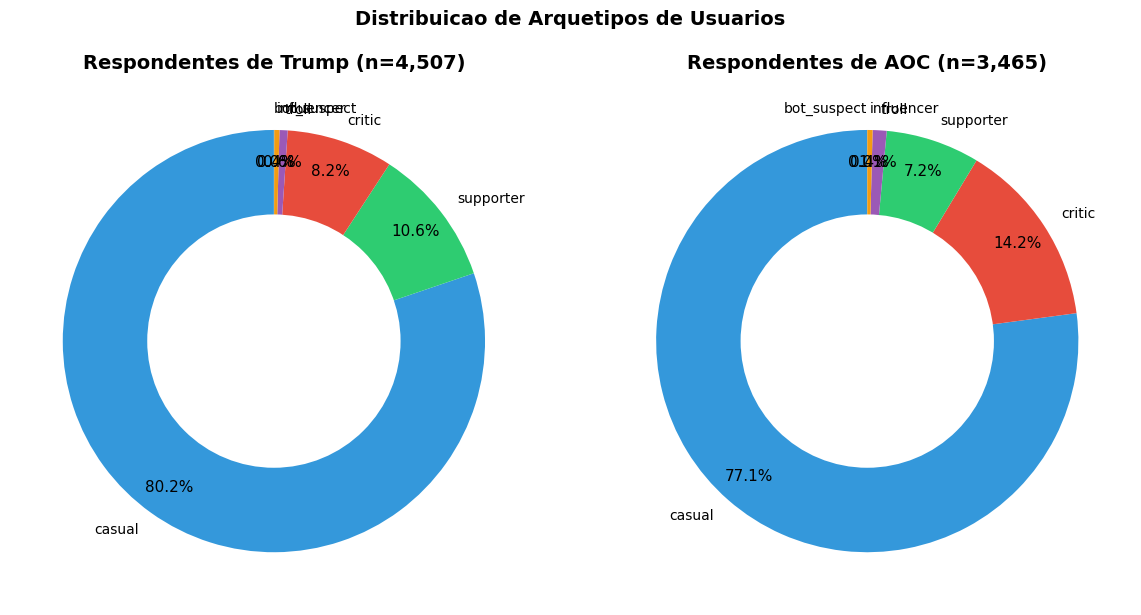

In [9]:
# Distribuicao de arquetipos por politico
trump_profiles = profiles[profiles['trump_replies'] > profiles['aoc_replies']]
aoc_profiles = profiles[profiles['aoc_replies'] > profiles['trump_replies']]

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

for ax, p_df, title in [
    (axes[0], trump_profiles, f"Respondentes de Trump (n={len(trump_profiles):,})"),
    (axes[1], aoc_profiles, f"Respondentes de AOC (n={len(aoc_profiles):,})"),
]:
    arch_counts = p_df['archetype'].value_counts()
    arch_colors = [ARCHETYPE_COLORS.get(a, '#999') for a in arch_counts.index]

    wedges, texts, autotexts = ax.pie(
        arch_counts.values, labels=arch_counts.index,
        colors=arch_colors, autopct='%1.1f%%',
        pctdistance=0.85, startangle=90
    )
    centre_circle = plt.Circle((0, 0), 0.60, fc='white')
    ax.add_artist(centre_circle)
    ax.set_title(title, fontweight='bold')

plt.suptitle('Distribuicao de Arquetipos de Usuarios', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Fingerprints comportamentais dos arquetipos:


,Contagem,Media Respostas,Media Texto,Media Curtidas,Media Delay (min),Media Hashtags,Menciona Politico %,Media Seguidores
archetype,,,,,,,,
bot_suspect,1,40.00,42.58,0.00,24239.70,0.00,1.0,87.00
casual,6291,1.47,94.06,0.34,53371.57,0.07,1.0,2486.95
critic,863,1.22,152.53,0.36,40204.31,0.04,1.0,1021.65
influencer,32,1.16,107.98,7.69,39408.44,0.09,1.0,74100.69
supporter,728,1.24,145.23,0.40,65543.13,0.05,1.0,835.63
troll,65,1.40,93.86,0.27,25218.84,0.05,1.0,745.45


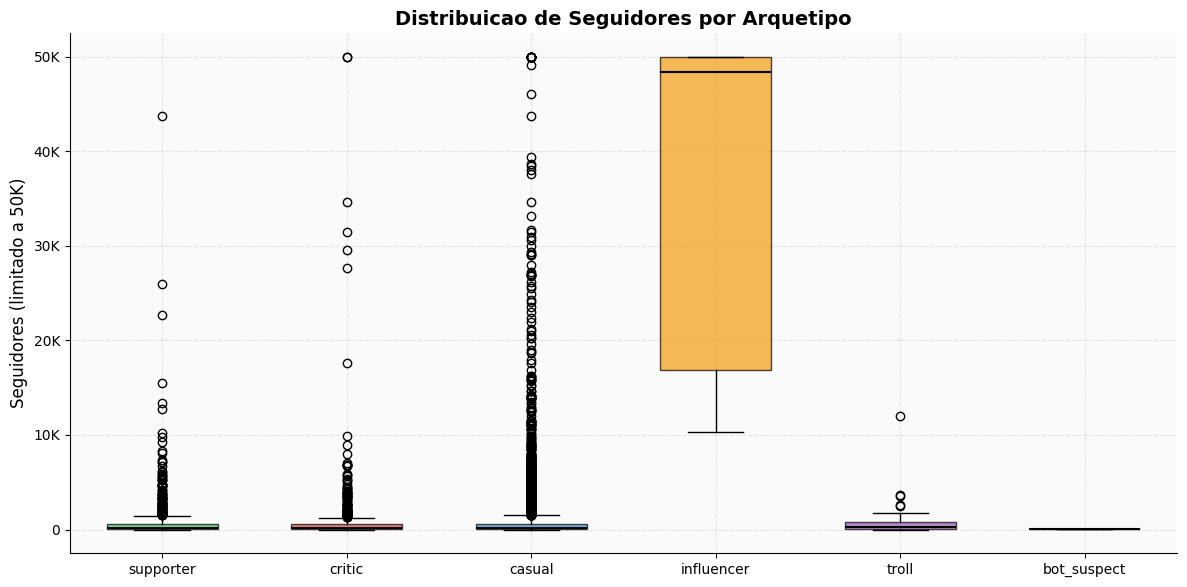

In [10]:
# Fingerprints comportamentais dos arquetipos
arch_features = profiles.groupby('archetype').agg(
    contagem=('user_name', 'count'),
    media_respostas=('total_replies', 'mean'),
    media_texto=('avg_text_length', 'mean'),
    media_curtidas=('avg_favorites_received', 'mean'),
    media_delay=('avg_reply_delay_minutes', 'mean'),
    media_hashtags=('avg_hashtag_count', 'mean'),
    menciona_parent_pct=('mentions_parent_pct', 'mean'),
    media_seguidores=('user_followers_count', 'mean'),
).round(2)

arch_features.columns = ['Contagem', 'Media Respostas', 'Media Texto', 'Media Curtidas',
                          'Media Delay (min)', 'Media Hashtags', 'Menciona Politico %', 'Media Seguidores']
print("Fingerprints comportamentais dos arquetipos:")
display(arch_features)

# Box plots: seguidores por arquetipo
fig, ax = plt.subplots(figsize=FIGURE_SIZE)
arch_order = ['supporter', 'critic', 'casual', 'influencer', 'troll', 'bot_suspect']
arch_order = [a for a in arch_order if a in profiles['archetype'].values]

data_by_arch = [profiles[profiles['archetype'] == a]['user_followers_count'].clip(upper=50000)
                for a in arch_order]

bp = ax.boxplot(data_by_arch, labels=arch_order, patch_artist=True, widths=0.6,
               medianprops={'color': 'black', 'linewidth': 1.5})
for patch, arch in zip(bp['boxes'], arch_order):
    patch.set_facecolor(ARCHETYPE_COLORS.get(arch, '#999'))
    patch.set_alpha(0.7)

ax.set_title('Distribuicao de Seguidores por Arquetipo', fontweight='bold')
ax.set_ylabel('Seguidores (limitado a 50K)')
format_large_numbers(ax)
plt.tight_layout()
plt.show()

In [11]:
# Exemplos representativos por arquetipo
print("Respostas representativas por arquetipo:\n")
for arch in ['supporter', 'critic', 'troll', 'influencer', 'bot_suspect']:
    arch_users = profiles[profiles['archetype'] == arch]['user_name'].values
    if len(arch_users) == 0:
        continue
    arch_replies = replies_df[replies_df['user_name'].isin(arch_users)]
    if arch_replies.empty:
        continue
    examples = arch_replies.nlargest(2, 'favorite_count')
    print(f"--- {arch.upper()} ---")
    for _, ex in examples.iterrows():
        text_preview = ex['text'][:150] + ('...' if len(str(ex['text'])) > 150 else '')
        print(f"  @{ex['user_name']} (respondendo a {ex['parent_user']}): \"{text_preview}\"")
        print(f"    Curtidas: {ex['favorite_count']:,} | Visualizacoes: {ex['view_count']:,}")
    print()

Respostas representativas por arquetipo:

--- SUPPORTER ---
  @Wess_Miller (respondendo a aoc): "@AOC @DianaforQueens @AOC, thank you for leading from the front!

@DianaforQueens, wishing you the best of luck!"
    Curtidas: 8 | Visualizacoes: 777
  @WitCephandrius (respondendo a aoc): "@DavidLHillPA @AOC She wasn't, you absolute retard. She was a locker room attendant. I swear Democrats are the dumbest people alive.

@grok Was Virgin..."
    Curtidas: 6 | Visualizacoes: 465

--- CRITIC ---
  @Achilles440617 (respondendo a trump): "@realDonaldTrump POTUS @realDonaldTrump, any foolish decision that risks the lives of over 60K 🇺🇸 personnel for a criminal lunatic as @netanyahu who w..."
    Curtidas: 26 | Visualizacoes: 10,130
  @existensil (respondendo a aoc): "@Bmmoody @AOC @DianaforQueens Even countries that run the public health programs poorly have far lower costs and better health outcomes than the US. Y..."
    Curtidas: 8 | Visualizacoes: 69

--- TROLL ---
  @barbgrant236565 (resp

=== O FENOMENO GROK ===
Grok (assistente de IA da xAI) esta ativo em ambas as secoes de resposta:

  Total de respostas: 233
  Respostas a Trump: 197
  Respostas a AOC: 36
  Arquetipo: casual
  Seguidores: 8,104,538
  Media de curtidas por resposta: 0.2
  Sentimento dominante: neutral


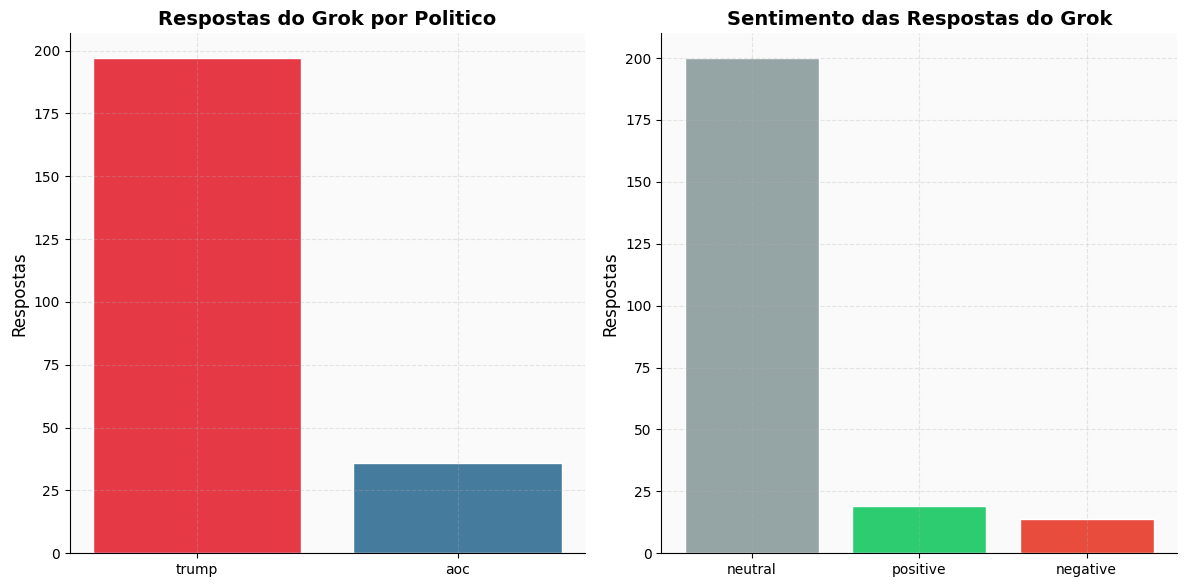

In [12]:
# O fenomeno Grok: bot de IA como top respondente
grok_profile = profiles[profiles['user_name'].str.lower() == 'grok']
grok_replies = replies_df[replies_df['user_name'].str.lower() == 'grok']

if not grok_profile.empty:
    print("=== O FENOMENO GROK ===")
    print(f"Grok (assistente de IA da xAI) esta ativo em ambas as secoes de resposta:\n")
    g = grok_profile.iloc[0]
    print(f"  Total de respostas: {g['total_replies']}")
    print(f"  Respostas a Trump: {g['trump_replies']}")
    print(f"  Respostas a AOC: {g['aoc_replies']}")
    print(f"  Arquetipo: {g['archetype']}")
    print(f"  Seguidores: {g['user_followers_count']:,.0f}")
    print(f"  Media de curtidas por resposta: {g['avg_favorites_received']:.1f}")
    print(f"  Sentimento dominante: {g['dominant_sentiment']}")

    if not grok_replies.empty:
        fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

        grok_by_pol = grok_replies['parent_user'].value_counts()
        grok_colors = [colors.get(p, '#999') for p in grok_by_pol.index]
        axes[0].bar(grok_by_pol.index, grok_by_pol.values, color=grok_colors, edgecolor='white')
        axes[0].set_title('Respostas do Grok por Politico', fontweight='bold')
        axes[0].set_ylabel('Respostas')

        grok_sent = grok_replies['sentiment_simple'].value_counts()
        sent_colors = {'positive': '#2ECC71', 'negative': '#E74C3C', 'neutral': '#95A5A6'}
        axes[1].bar(grok_sent.index, grok_sent.values,
                   color=[sent_colors.get(s, '#999') for s in grok_sent.index],
                   edgecolor='white')
        axes[1].set_title('Sentimento das Respostas do Grok', fontweight='bold')
        axes[1].set_ylabel('Respostas')

        plt.tight_layout()
        plt.show()
else:
    print("Grok nao encontrado no dataset de respondentes.")

**O que isso nos diz?** A distribuicao de arquetipos revela a composicao do publico de cada politico. A presenca de bots de IA como o Grok participando do discurso politico e uma descoberta netnografica inedita — levanta questoes sobre a autenticidade e natureza organica das conversas politicas online.

---
## 5. Profundidade da Conversa: Alem das Respostas de Primeiro Nivel

Visao geral da profundidade da conversa:
  Usuarios cujas respostas geraram sub-threads: 598 (7.5%)
  Total de sub-respostas geradas: 1,548


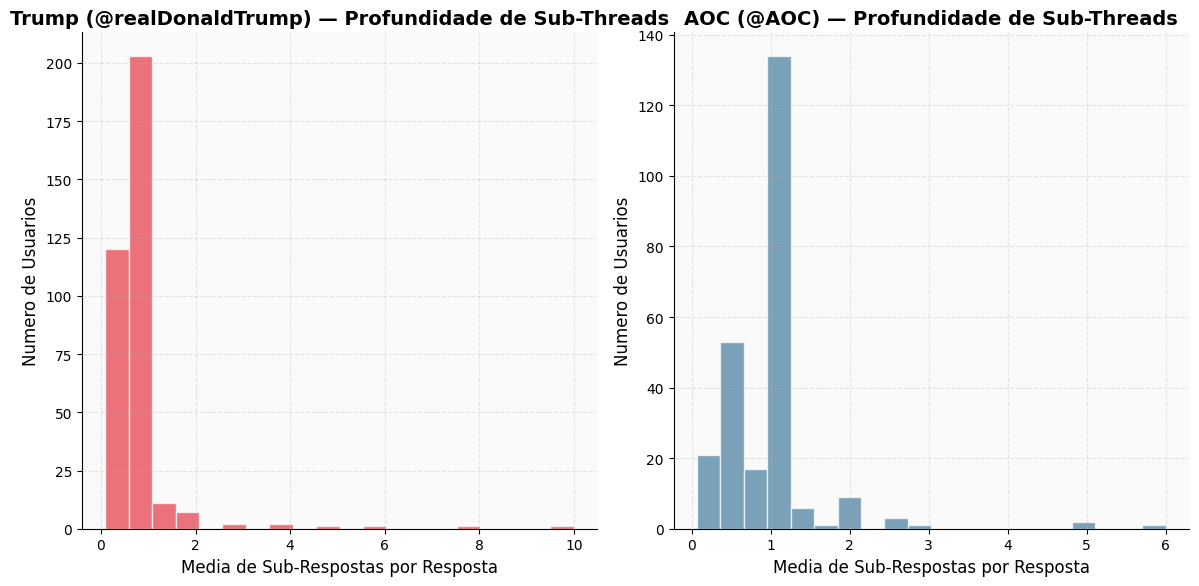

In [13]:
# Analise de sub-threads
total_with_subreplies = (profiles['replies_with_subreplies'] > 0).sum()
total_subreply_volume = profiles['total_subreply_count'].sum()

print(f"Visao geral da profundidade da conversa:")
print(f"  Usuarios cujas respostas geraram sub-threads: {total_with_subreplies:,} ({total_with_subreplies/len(profiles)*100:.1f}%)")
print(f"  Total de sub-respostas geradas: {total_subreply_volume:,}")

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

for ax, pol, color in [(axes[0], 'trump', colors['trump']), (axes[1], 'aoc', colors['aoc'])]:
    pol_profiles = profiles[profiles[f'{pol}_replies'] > profiles[('aoc' if pol == 'trump' else 'trump') + '_replies']]
    subreply_dist = pol_profiles['avg_subreply_count'].clip(upper=10)
    ax.hist(subreply_dist[subreply_dist > 0], bins=20, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'{get_user_label(pol)} — Profundidade de Sub-Threads', fontweight='bold')
    ax.set_xlabel('Media de Sub-Respostas por Resposta')
    ax.set_ylabel('Numero de Usuarios')

plt.tight_layout()
plt.show()

In [14]:
# Analise de reciprocidade de mencoes
edges_set = set()
for _, row in mention_edges.iterrows():
    edges_set.add((row['source'], row['target']))

reciprocal_pairs = []
for _, row in mention_edges.iterrows():
    if (row['target'], row['source']) in edges_set:
        pair = tuple(sorted([row['source'], row['target']]))
        reciprocal_pairs.append(pair)

reciprocal_unique = set(reciprocal_pairs)
total_edges = len(mention_edges)

print(f"\nReciprocidade na conversa:")
print(f"  Total de arestas de mencao dirigidas: {total_edges:,}")
print(f"  Pares reciprocos (A<->B): {len(reciprocal_unique):,}")
print(f"  Taxa de reciprocidade: {len(reciprocal_unique)*2/total_edges*100:.1f}%")

if reciprocal_unique:
    print(f"\n  Top pares reciprocos (conversas de ida e volta):")
    pair_weights = {}
    for a, b in reciprocal_unique:
        w1 = mention_edges[(mention_edges['source']==a) & (mention_edges['target']==b)]['weight'].sum()
        w2 = mention_edges[(mention_edges['source']==b) & (mention_edges['target']==a)]['weight'].sum()
        pair_weights[(a,b)] = w1 + w2

    for (a, b), w in sorted(pair_weights.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f"    {a} <-> {b} (mencoes combinadas: {w})")


Reciprocidade na conversa:
  Total de arestas de mencao dirigidas: 5,036
  Pares reciprocos (A<->B): 258
  Taxa de reciprocidade: 10.2%

  Top pares reciprocos (conversas de ida e volta):


    Darealynsny <-> TheSportPigeon (mencoes combinadas: 79)
    GerryRiver55569 <-> teapartytempest (mencoes combinadas: 62)
    TheSportPigeon <-> TokyoRobb (mencoes combinadas: 62)
    Jaythewolf1 <-> TheSportPigeon (mencoes combinadas: 56)
    allgoodmight <-> grok (mencoes combinadas: 48)
    TheSportPigeon <-> grok (mencoes combinadas: 47)
    muy_bro89458 <-> sheluvvmikeyyyy (mencoes combinadas: 44)
    PopTartsdSmores <-> teapartytempest (mencoes combinadas: 33)
    Darealynsny <-> Jaythewolf1 (mencoes combinadas: 33)
    5CYBJo3cm50uSxR <-> grok (mencoes combinadas: 30)


**O que isso nos diz?** A maioria das respostas de primeiro nivel sao becos sem saida conversacionais — nao geram mais discussao. A taxa de reciprocidade revela quanto *dialogo real* ocorre nas secoes de resposta versus comentarios estilo monologo.

---
## 6. Como o Engajamento Evolui ao Longo do Tempo

Respondentes recorrentes (5+ respostas): 200 usuarios, 2109 respostas


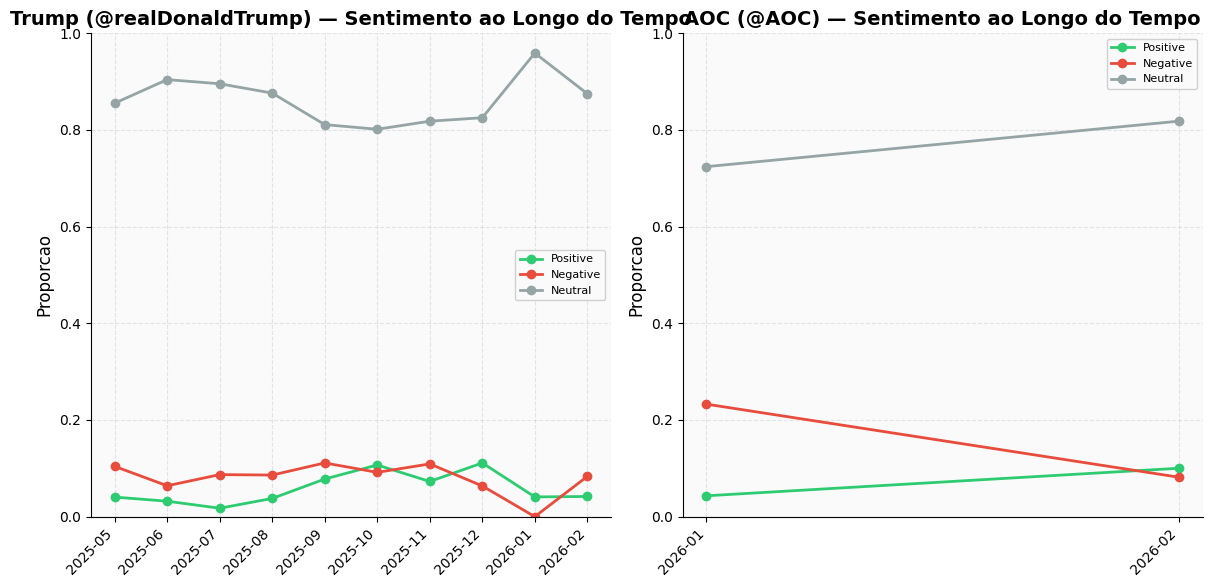

In [15]:
# Padroes temporais de engajamento para respondentes recorrentes
repeat_users = profiles[profiles['total_replies'] >= 5]['user_name'].values
repeat_replies = replies_df[replies_df['user_name'].isin(repeat_users)].copy()

print(f"Respondentes recorrentes (5+ respostas): {len(repeat_users)} usuarios, {len(repeat_replies)} respostas")

repeat_replies['month'] = repeat_replies['created_at'].dt.to_period('M')

monthly_sentiment = repeat_replies.groupby(['month', 'parent_user', 'sentiment_simple']).size().unstack(fill_value=0)
monthly_sentiment = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

sent_colors = {'positive': '#2ECC71', 'negative': '#E74C3C', 'neutral': '#95A5A6'}

for ax, pol, color in [(axes[0], 'trump', colors['trump']), (axes[1], 'aoc', colors['aoc'])]:
    pol_data = monthly_sentiment.xs(pol, level='parent_user') if pol in monthly_sentiment.index.get_level_values('parent_user') else pd.DataFrame()
    if not pol_data.empty:
        for sent in ['positive', 'negative', 'neutral']:
            if sent in pol_data.columns:
                ax.plot(range(len(pol_data)), pol_data[sent].values,
                       marker='o', label=sent.title(), color=sent_colors[sent], linewidth=2)
        ax.set_xticks(range(len(pol_data)))
        ax.set_xticklabels([str(p) for p in pol_data.index], rotation=45, ha='right')
    ax.set_title(f'{get_user_label(pol)} — Sentimento ao Longo do Tempo', fontweight='bold')
    ax.set_ylabel('Proporcao')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

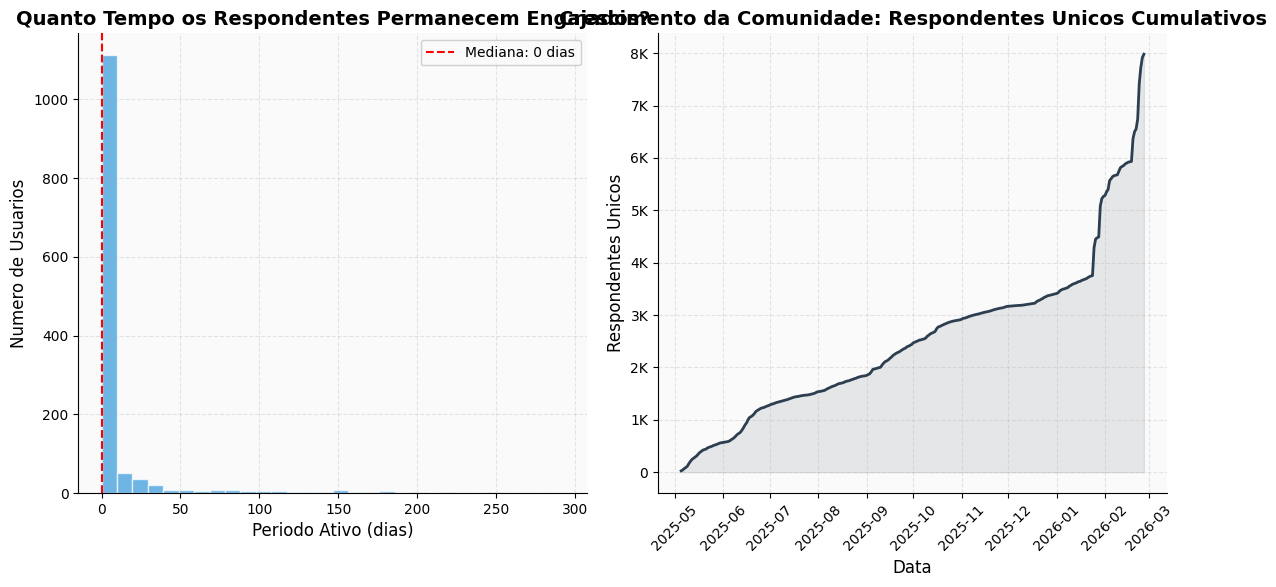


Analise de lealdade:
  Respondentes unicos: 6,662 (83.5%)
  Usuarios leais (3+ tweets, 30+ dias ativos): 30 (0.4%)


In [16]:
# Lealdade e churn de usuarios
fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

active_spans = profiles[profiles['active_span_days'] > 0]['active_span_days']
axes[0].hist(active_spans, bins=30, color='#3498DB', alpha=0.7, edgecolor='white')
axes[0].axvline(active_spans.median(), color='red', linestyle='--', label=f'Mediana: {active_spans.median():.0f} dias')
axes[0].set_title('Quanto Tempo os Respondentes Permanecem Engajados?', fontweight='bold')
axes[0].set_xlabel('Periodo Ativo (dias)')
axes[0].set_ylabel('Numero de Usuarios')
axes[0].legend()

replies_sorted = replies_df.sort_values('created_at')
seen_users = set()
cumulative = []
dates = []
for date, group in replies_sorted.groupby(replies_sorted['created_at'].dt.date):
    seen_users.update(group['user_name'].unique())
    cumulative.append(len(seen_users))
    dates.append(date)

axes[1].plot(dates, cumulative, color='#2C3E50', linewidth=2)
axes[1].fill_between(dates, cumulative, alpha=0.1, color='#2C3E50')
axes[1].set_title('Crescimento da Comunidade: Respondentes Unicos Cumulativos', fontweight='bold')
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Respondentes Unicos')
format_large_numbers(axes[1])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

one_timers = (profiles['total_replies'] == 1).sum()
loyal = ((profiles['unique_tweets_replied'] >= 3) & (profiles['active_span_days'] >= 30)).sum()
print(f"\nAnalise de lealdade:")
print(f"  Respondentes unicos: {one_timers:,} ({one_timers/len(profiles)*100:.1f}%)")
print(f"  Usuarios leais (3+ tweets, 30+ dias ativos): {loyal:,} ({loyal/len(profiles)*100:.1f}%)")

**O que isso nos diz?** A distribuicao do periodo ativo revela se as comunidades consistem de participantes persistentes ou visitantes transitorios. Altas taxas de respondentes unicos sugerem que a maioria do engajamento e efemero — as pessoas reagem a um unico tweet e seguem em frente.

---
## 7. Usuarios Ponte: Quem Interage com Ambos os Politicos?

Usuarios que responderam a AMBOS Trump e AOC: 10
De 7,980 respondentes totais, isso representa 0.13%



,Usuario,Respostas Trump,Respostas AOC,Total,Seguidores,Sentimento,Arquetipo
1,grok,197,36,233,"8,104,538",neutral,casual
2,Firefish65,4,1,5,310,neutral,casual
3,Fareplease1con,1,1,2,37,negative,critic
4,ChristinaHambu4,1,1,2,"7,330",neutral,casual
5,KCKCBeliever,1,1,2,80,neutral,casual
6,Grumpy_MAGA,1,1,2,315,negative,critic
7,Kathlee61566208,1,1,2,59,neutral,casual
8,RonnieIsaacs3,1,1,2,287,neutral,casual
9,jjohnson1036915,1,1,2,13,positive,supporter
10,pal_98057,1,1,2,"5,722",positive,supporter


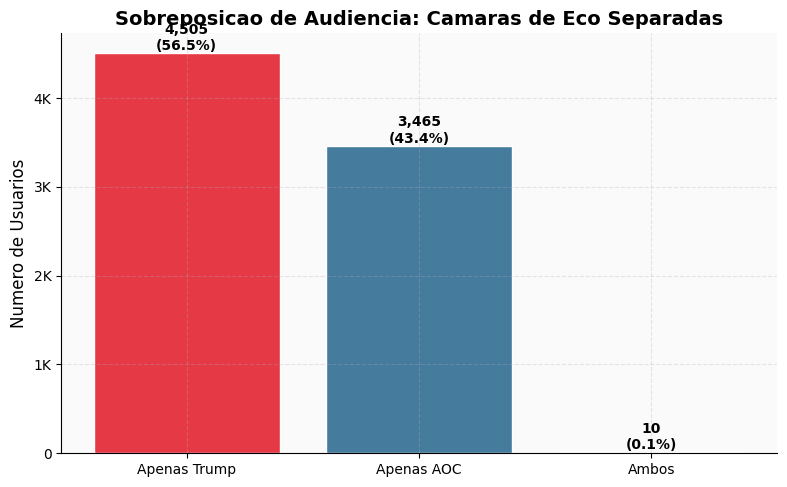

In [17]:
# Analise de engajamento entre perfis
bridge_users = profiles[profiles['is_cross_profile']].sort_values('total_replies', ascending=False)

print(f"Usuarios que responderam a AMBOS Trump e AOC: {len(bridge_users)}")
print(f"De {len(profiles):,} respondentes totais, isso representa {len(bridge_users)/len(profiles)*100:.2f}%")
print()

if not bridge_users.empty:
    display_cols = ['user_name', 'trump_replies', 'aoc_replies', 'total_replies',
                    'user_followers_count', 'dominant_sentiment', 'archetype']
    display_df = bridge_users[display_cols].copy()
    display_df.columns = ['Usuario', 'Respostas Trump', 'Respostas AOC', 'Total',
                          'Seguidores', 'Sentimento', 'Arquetipo']
    display_df['Seguidores'] = display_df['Seguidores'].apply(lambda x: f"{x:,.0f}")
    display_df = display_df.reset_index(drop=True)
    display_df.index += 1
    display(display_df)

# Visualizacao de sobreposicao de audiencia
fig, ax = plt.subplots(figsize=FIGURE_SIZE_SMALL)
trump_only = (profiles['trump_replies'] > 0) & (profiles['aoc_replies'] == 0)
aoc_only = (profiles['aoc_replies'] > 0) & (profiles['trump_replies'] == 0)
both = profiles['is_cross_profile']

categories = ['Apenas Trump', 'Apenas AOC', 'Ambos']
counts = [trump_only.sum(), aoc_only.sum(), both.sum()]
bar_colors = [colors['trump'], colors['aoc'], '#9B59B6']

bars = ax.bar(categories, counts, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, counts):
    pct = val / len(profiles) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
           f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Sobreposicao de Audiencia: Camaras de Eco Separadas', fontweight='bold')
ax.set_ylabel('Numero de Usuarios')
format_large_numbers(ax)
plt.tight_layout()
plt.show()

**O que isso nos diz?** A separacao quase total das audiencias e uma das descobertas netnograficas mais fortes deste estudo. Com apenas um punhado de usuarios interagindo com ambos os politicos, os dados fornecem evidencia empirica para o fenomeno de **camara de eco politica** no Twitter/X.

---
## 8. Principais Conclusoes

### Estrutura da Rede
A rede de mencoes em respostas exibe uma distribuicao de grau em lei de potencia, com um pequeno numero de usuarios hub dominando a estrutura da conversa. A analise de PageRank revela lideres de opiniao especificos da comunidade.

### Clusters Comportamentais
O clustering KMeans identifica grupos comportamentais distintos entre os respondentes, desde comentaristas passivos ate super-respondentes altamente ativos.

### Arquetipos de Usuarios
A classificacao baseada em regras identifica apoiadores, criticos, trolls, possiveis bots e influenciadores. A maioria dos respondentes sao comentaristas casuais, mas as pequenas porcentagens de trolls e criticos moldam desproporcionalmente o tom da conversa.

### Participacao de IA
A presenca do Grok como respondente prolifico nas threads de ambos os politicos levanta questoes importantes sobre a autenticidade do discurso politico online.

### Profundidade da Conversa
A maioria das respostas de primeiro nivel sao becos sem saida conversacionais. O dialogo verdadeiro (mencoes reciprocas) e raro, sugerindo que as secoes de resposta politicas funcionam mais como canais de transmissao do que espacos de discurso genuino.

### Camaras de Eco
A sobreposicao quase nula entre os pools de respondentes de Trump e AOC fornece forte evidencia empirica para camaras de eco politicas no Twitter/X.